In [2]:
import os
import math
import cv2
import numpy as np
import pandas as pd
from scipy import interpolate, signal
from pathlib import Path
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, r'C:\Users\nVoke\PycharmProjects\pythonProject1\tools')
from scan import scan_file

from matplotlib import pyplot as plt
%matplotlib inline

'''
    install cv2: pip install opencv-python -i https://pypi.tuna.tsinghua.edu.cn/simple
'''

'\n    install cv2: pip install opencv-python -i https://pypi.tuna.tsinghua.edu.cn/simple\n'

<img src='../image/cell_body.png' style='width: 500px' />

Morphology Features
- Soma area
- Primary dendrite number
- Node number
- Ending number
- Process area
- Total dendritic length
- Mean dendritic length = Total Length / Primary dendrite number

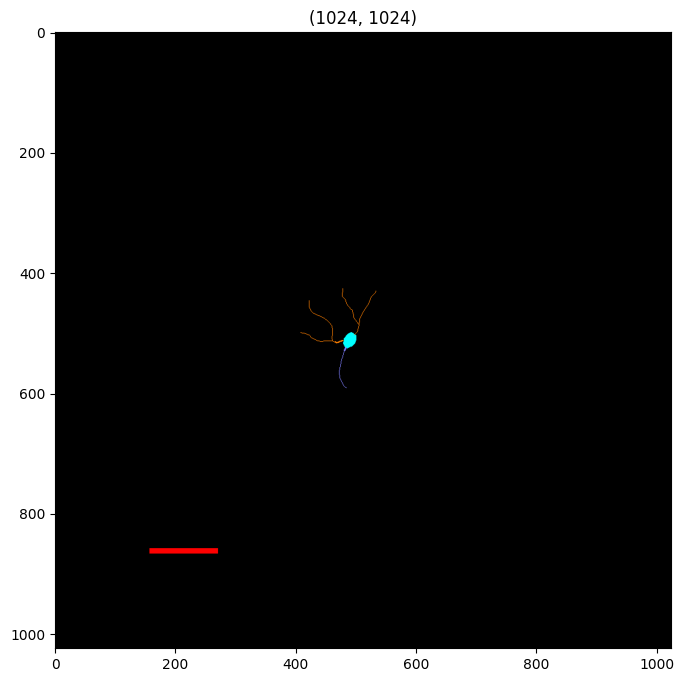

In [3]:
fpath = r'F:\jcy\humen_brain\electrophysiology\reconstruction\biotin_reconstructed\occipital_lobe\inhibitory\BC'

img = Image.open(fpath+'\\occipital_lobe_1121_slice1_cell4.tif')
x = np.array(img)
height, width, _ = x.shape

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.title(f'{img.size}')
plt.show()

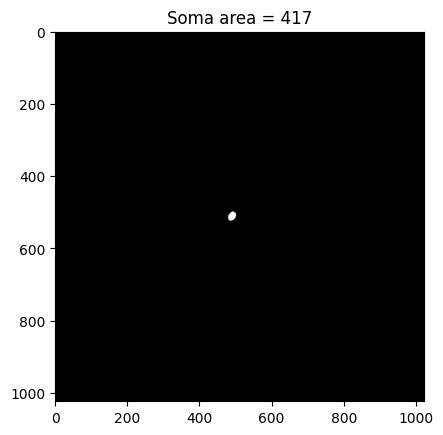

In [4]:
# 胞体面积 = 青色区域的像素点数量
r, g, b = x[:,:,0], x[:,:,1], x[:,:,2]

soma = np.where((r == 0) & (g == 255) & (b == 255), 255, 0).astype(np.uint8)

soma_area = np.count_nonzero(soma)

plt.imshow(soma, cmap='gray')
plt.title(f'Soma area = {soma_area}')
plt.show()

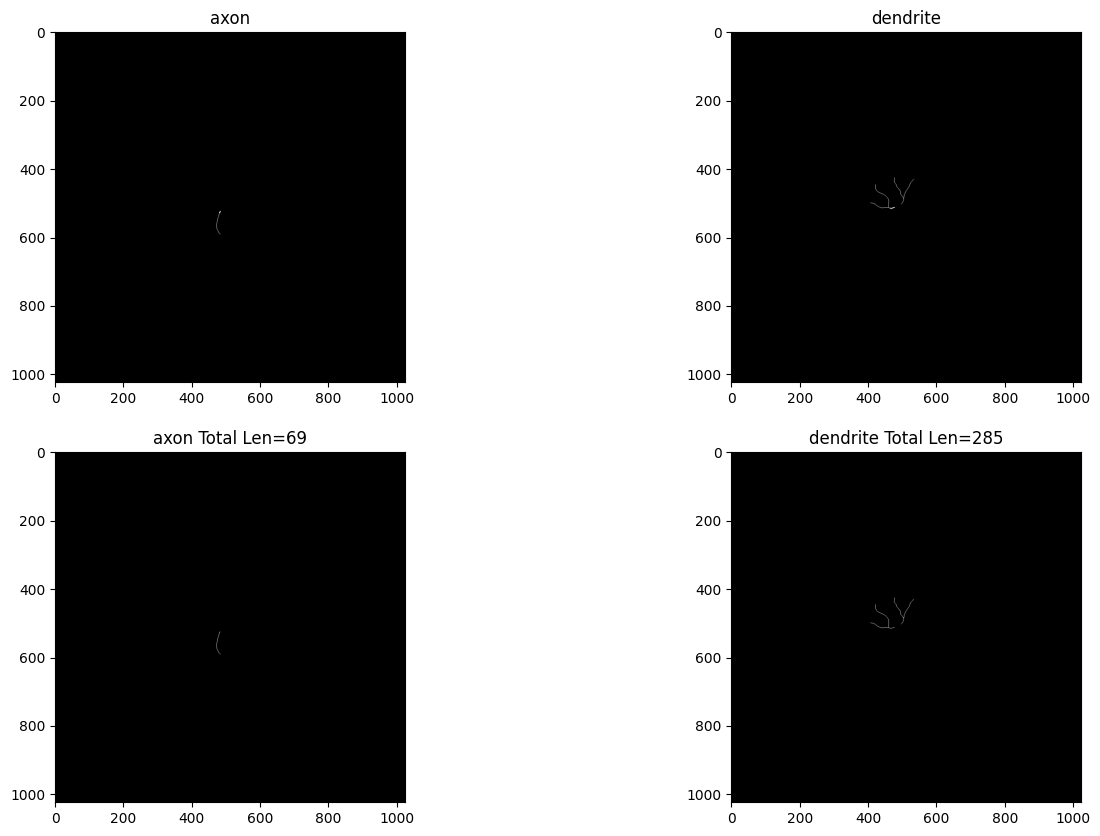

In [ ]:
axon_branch = np.where((r == 128) & (g == 128) & (b >= 192), 255, 0).astype(np.uint8)
dend_branch = np.where((r == 255) & (g == 128) & (b == 0), 255, 0).astype(np.uint8)

axon_skeleton = cv2.ximgproc.thinning(axon_branch)
dend_skeleton = cv2.ximgproc.thinning(dend_branch)

len_axon = np.count_nonzero(axon_skeleton)
len_dend = np.count_nonzero(dend_skeleton)

# cv2.imwrite(outpath+'\\dendrite.png', dend_skeleton)

plt.figure(figsize=(16, 10))
plt.subplot(221); plt.imshow(axon_branch, cmap='gray'); plt.title('axon')
plt.subplot(222); plt.imshow(dend_branch, cmap='gray'); plt.title('dendrite')

plt.subplot(223); plt.imshow(axon_skeleton, cmap='gray'); plt.title(f'axon Total Len={len_axon}')
plt.subplot(224); plt.imshow(dend_skeleton, cmap='gray'); plt.title(f'dendrite Total Len={len_dend}')

plt.show()

In [ ]:

contours, _ = cv2.findContours(soma, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
(dx, dy), dr = cv2.minEnclosingCircle(contours[0])

soma_mask = np.zeros_like(soma)
cv2.circle(soma_mask, (int(dx), int(dy)), int(dr + 10), 255, -1)

dend_check = dend_branch * (soma_mask == 255)

contours, _ = cv2.findContours(dend_check, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

# primary dendrite num
len(contours), dx, dy, dr

(1, 497.0, 503.0, 1.000100016593933)

In [ ]:

arr_h, arr_w = np.where((r == 255) & (g == 0) & (b == 0))
# arr_h, arr_w = np.where((r == 0) & (g == 255) & (b == 0))

mark_len = arr_w.max() - arr_w.min() + 1

mark_len, arr_h.min(), arr_h.max(), arr_w.min(), arr_w.max(),

(114, 858, 866, 157, 270)

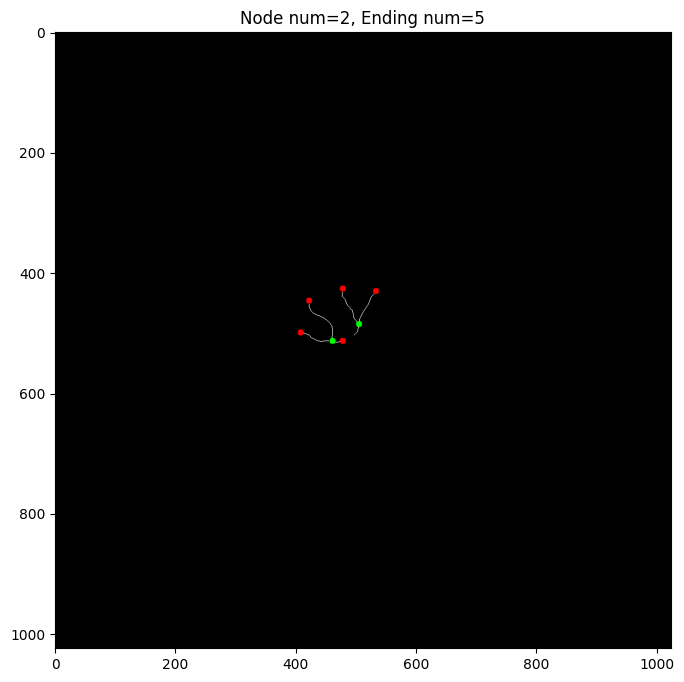

In [ ]:

def merge_near_points(arr_h, arr_w, thresh_len = 8, skip_border = False):

    N = len(arr_h)

    skip_ids = []
    for i in range(N):
        x, y = arr_h[i], arr_w[i]

        if skip_border:
            dh = min(x, abs(height-x))
            dw = min(y, abs(width-y))
            if dh < 3 or dw < 3:
                skip_ids.append(i)
                continue

        for j in range(i + 1, N):
            dist = math.sqrt((x - arr_h[j]) ** 2 + (y - arr_w[j]) ** 2)
            if dist < thresh_len:
                skip_ids.append(i)
                break

    # print(f'skip {len(skip_ids)} cross points')

    valid_ids = np.setdiff1d(list(range(N)), skip_ids).astype(int)
    return arr_h[valid_ids], arr_w[valid_ids]

def find_cross_points(binary):

    kernel1 = np.array([[1, 0, 1], 
                        [0, 3, 0], 
                        [0, 1, 0]])

    kernel2 = np.array([[0, 1, 0], 
                        [1, 3, 1], 
                        [0, 0, 0]])

    kernel3 = np.array([[0, 1, 0], 
                        [0, 3, 1], 
                        [1, 0, 0]])

    kernel4 = np.array([[1, 0, 1], 
                        [0, 3, 0], 
                        [0, 0, 1]])

    cross_flags = np.zeros_like(binary).astype(bool)

    for k in [kernel1, kernel2, kernel3, kernel4]:
        k1 = k
        # k1 = np.where(k == 0, -1, k)
        
        k2 = cv2.rotate(k1, cv2.ROTATE_90_CLOCKWISE)
        k3 = cv2.rotate(k2, cv2.ROTATE_90_CLOCKWISE)
        k4 = cv2.rotate(k3, cv2.ROTATE_90_CLOCKWISE)
        
        for kernel in [k1, k2, k3, k4]:
            flags = cv2.filter2D(binary, -1, kernel)
            cross_flags = cross_flags | (flags >= 6)

    arr_h, arr_w = np.where(cross_flags)

    return merge_near_points(arr_h, arr_w)

def find_end_points(binary):
    k1 = np.array([
        [1, 1, 1], 
        [1, 10, 1], 
        [1, 1, 1]])
    
    end_flags = np.zeros_like(binary).astype(bool)
    y = signal.convolve2d(binary, k1, mode='same')
    end_flags = end_flags | (y == 11)

    k1 = np.array([
        [-1, -1, -1],
        [-1, 50, -1], 
        [10, 30, 10]])

    k2 = cv2.rotate(k1, cv2.ROTATE_90_CLOCKWISE)
    k3 = cv2.rotate(k2, cv2.ROTATE_90_CLOCKWISE)
    k4 = cv2.rotate(k3, cv2.ROTATE_90_CLOCKWISE)

    for kernel in [k1, k2, k3, k4]:
        y = signal.convolve2d(binary, kernel, mode='same')
        end_flags = end_flags | (y == 90)

    arr_h, arr_w = np.where(end_flags)

    return merge_near_points(arr_h, arr_w)

binary = (dend_skeleton / 255).astype(np.uint8)

thin1 = cv2.cvtColor(dend_skeleton, cv2.COLOR_GRAY2BGR)
thin2 = dend_skeleton.copy()

cross_h, cross_w = find_cross_points(binary)

eh, ew = find_end_points(binary)

end_h, end_w = [], [] 
for h, w in zip(eh, ew):
    dist = math.sqrt((h-dy)**2 + (w-dx)**2)
    if dist - dr < 15:
        continue

    end_h.append(h)
    end_w.append(w)

for h, w in zip(cross_h, cross_w):
    cv2.circle(thin1, (w, h), 5, (0, 255, 0), -1)

for h, w in zip(end_h, end_w):
    cv2.circle(thin1, (w, h), 5, (255, 0, 0), -1)

plt.figure(figsize=(12, 8))
plt.imshow(thin1); plt.title(f'Node num={len(cross_w)}, Ending num={len(end_w)}')
# plt.subplot(212); plt.imshow(mark_img); plt.title(f'branches (n={n_branch})')
plt.show()

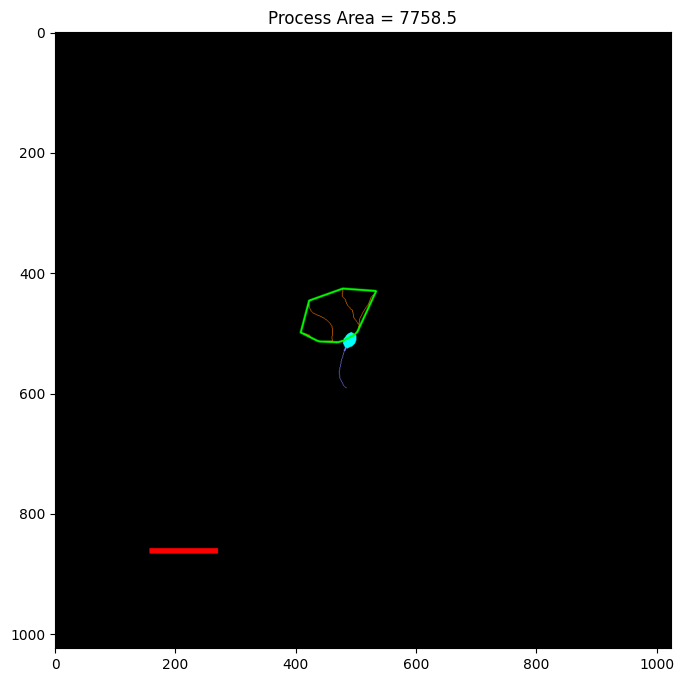

In [ ]:
def find_conv_hull(binary):
    y = np.where(binary > 0)

    points = np.expand_dims(np.stack([y[1], y[0]], axis=1), 1)
    hull = cv2.convexHull(points)

    area_hull = cv2.contourArea(hull)

    return area_hull, hull

area_hull, hull = find_conv_hull(binary)

mark_img = np.array(img)

cv2.drawContours(mark_img, [hull], -1, (0, 255, 0), 2, cv2.LINE_AA)

plt.figure(figsize=(12, 8))
plt.imshow(mark_img)
plt.title(f'Process Area = {area_hull}')
plt.show()

In [ ]:
def get_morphology_features(fpath: Path, out_dir: Path = None):
    
    if type(fpath) is str:
        fpath = Path(fpath)

    x = cv2.imread(str(fpath))
    height, width, _ = x.shape

    b, g, r = cv2.split(x)

    soma = np.where((r == 0) & (g == 255) & (b == 255), 255, 0).astype(np.uint8)
    axon_branch = np.where((r == 128) & (g == 128) & (b >= 192), 255, 0).astype(np.uint8)
    dend_branch = np.where((r == 255) & (g == 128) & (b == 0), 255, 0).astype(np.uint8)

    axon_skeleton = cv2.ximgproc.thinning(axon_branch)
    dend_skeleton = cv2.ximgproc.thinning(dend_branch)

    soma_surface_area = np.count_nonzero(soma)
    dentrite_total_length = np.count_nonzero(dend_skeleton)
    axon_total_length = np.count_nonzero(axon_skeleton)

    contours, _ = cv2.findContours(soma, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
    (dx, dy), dr = cv2.minEnclosingCircle(contours[0])

    soma_mask = np.zeros_like(soma)
    cv2.circle(soma_mask, (int(dx), int(dy)), int(dr + 10), 255, -1)

    dend_check = dend_branch * (soma_mask == 255)

    contours, _ = cv2.findContours(dend_check, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

    dentrite_exiting_soma = len(contours)
    dentrite_mean_length = dentrite_total_length / dentrite_exiting_soma

    binary = (dend_skeleton / 255).astype(np.uint8)
    cross_h, cross_w = find_cross_points(binary)
    
    eh, ew = find_end_points(binary)

    end_h, end_w = [], [] 
    for h, w in zip(eh, ew):
        dist = math.sqrt((h-dy)**2 + (w-dx)**2)
        if dist - dr < 15:
            continue

        end_h.append(h)
        end_w.append(w)

    area_hull, hull = find_conv_hull(binary)

    arr_h, arr_w = np.where((r == 255) & (g == 0) & (b == 0))
    # arr_h, arr_w = np.where((r ==0) & (g == 255) & (b == 0))
    pixel_size = arr_w.max() - arr_w.min() + 1
    pixel_len=0.05/pixel_size ###unit: mm

    if not out_dir is None:
        if type(out_dir) is str:
            out_dir = Path(out_dir)

        mark_img = x.copy()

        for h, w in zip(cross_h, cross_w):
            cv2.circle(mark_img, (w, h), 6, (0, 255, 0), -1)

        for h, w in zip(end_h, end_w):
            cv2.circle(mark_img, (w, h), 6, (0, 0, 255), -1)

        cv2.circle(mark_img, (int(dx), int(dy)), int(dr + 10), (0, 0, 255), 2)

        cv2.drawContours(mark_img, [hull], -1, (0, 255, 0), 2, cv2.LINE_AA)

        cv2.imwrite(str(out_dir / (fpath.stem + '.png')), mark_img)

        cv2.imwrite(str(out_dir / ('den_' + fpath.stem + '.png')), dend_skeleton)

    return height, width, soma_surface_area, axon_total_length, dentrite_exiting_soma, dentrite_total_length, round(dentrite_mean_length, 1), \
        len(cross_h), len(end_h), int(area_hull), pixel_size,pixel_len, fpath.name,fpath.name[:8], int(dx), int(dy)
    # return height, width, soma_area, num_primary_dend, total_len_dend, round(mean_len_dend, 1), \
    #     len(cross_h), len(end_h), int(area_hull), pixel_len, fpath.name,fpath.name[:8], int(dx), int(dy)

In [ ]:
from pathlib import Path
def scan_file(path: Path, file_info: list):

    # extensions = ['xml', 'png', 'jpg']

    extensions = ['tif']
    for f in path.iterdir():

        if f.is_file() and f.suffix[1:] in extensions: 
            file_info.append([f.name, f.suffix[1:], str(path)])

        elif f.is_dir() and str(f)[-12:]!='non_pv_homer':
            scan_file(f,file_info)
    return file_info

In [ ]:
# img_dir = Path('../data/cells/')

fpath = r'F:\jcy\humen_brain\electrophysiology\reconstruction\biotin_reconstructed'

img_dir =Path(fpath)
out_dir =Path(fpath+'\img_procession')
if not out_dir.exists():
    out_dir.mkdir()

features = []
file_info=[]
file_info = scan_file(img_dir,file_info)
df = pd.DataFrame(file_info, columns=['filename', 'ext', 'dir'])

for fname, dir in zip(df.filename, df.dir):
    print(f'Proc: {fname}')
    fpath_name = os.path.join(dir, fname)

    features.append(get_morphology_features(fpath_name, out_dir))

# for f in img_dir.glob('*.tif'):
#     print(f'Proc: {f.name}')
#     features.append(get_morphology_features(f, out_dir))

cols = ['Height', 'Width', 'soma_surface_area', 'axon_total_length', 'dentrite_exiting_soma', 'dentrite_total_length', 'dentrite_mean_length', 'dentrite_node_number', \
        'dentrite_ending_number', 'dendritic_field_area', 'pixel_size','pixel_len', 'Filename','region', 'Soma_w', 'Soma_h']

df = pd.DataFrame(features, columns = cols)

k = df.pixel_len.min()
df['zoom_ratio'] = df.pixel_len / k

df['axon_total_length'] = df['axon_total_length'] * df['pixel_len']
df['dentrite_total_length'] = df['dentrite_total_length'] * df['pixel_len']
df['dentrite_mean_length'] = df['dentrite_mean_length'] * df['pixel_len']

df['soma_surface_area'] = df['soma_surface_area'] * df['pixel_len'] * df['pixel_len']
df['dendritic_field_area'] = df['dendritic_field_area'] * df['pixel_len'] * df['pixel_len']

df.to_csv(out_dir / 'features.csv', index=None)

Proc: frontal_lobe_1123_slice1_cell10.tif
Proc: frontal_lobe_1123_slice1_cell11.tif
Proc: frontal_lobe_1123_slice1_cell12.tif
Proc: frontal_lobe_1123_slice1_cell13.tif
Proc: frontal_lobe_1123_slice1_cell14.tif
Proc: frontal_lobe_1123_slice1_cell15.tif
Proc: frontal_lobe_1123_slice1_cell17.tif
Proc: frontal_lobe_1123_slice1_cell18.tif
Proc: frontal_lobe_1123_slice1_cell19.tif
Proc: frontal_lobe_1123_slice1_cell21.tif
Proc: frontal_lobe_1123_slice1_cell22.tif
Proc: frontal_lobe_1123_slice1_cell23.tif
Proc: frontal_lobe_1123_slice1_cell24.tif
Proc: frontal_lobe_1123_slice1_cell25.tif
Proc: frontal_lobe_1123_slice1_cell6.tif
Proc: frontal_lobe_1123_slice1_cell8.tif
Proc: frontal_lobe_1207_slice2_cell2.tif
Proc: frontal_lobe_1207_slice2_cell3.tif
Proc: frontal_lobe_1207_slice2_cell5.tif
Proc: frontal_lobe_1207_slice2_cell6.tif
Proc: frontal_lobe_1207_slice2_cell7.tif
Proc: frontal_lobe_1207_slice2_cell8.tif
Proc: occipital_lobe_1121_slice1_cell4.tif
Proc: occipital_lobe_1121_slice1_cell6.ti

In [ ]:

def xy_img2center(pw: np.array, ph: np.array, center_w: int, center_h: int):
    return pw - center_w, center_h - ph

def xy_center2img(px: np.array, py: np.array, LT_x: int, LT_y: int):
    return np.abs(px - LT_x).astype(int), np.abs(py - LT_y).astype(int)

all_dx, all_dy, all_ax, all_ay, all_sx, all_sy = [], [], [], [],[],[]
for fname, soma_x, soma_y, zoom_ratio in zip(df.Filename, df.Soma_w, df.Soma_h, df.zoom_ratio):
    print(f'Proc: {fname}, {zoom_ratio}')
    
    img = cv2.imread(str(img_dir/fname))
    img.show()

    b, g, r = cv2.split(img)
    
    ay, ax = np.where((r == 128) & (g == 128) & (b >= 192))
    dy, dx = np.where((r == 255) & (g == 128) & (b == 0))
    sy, sx = np.where((r == 0) & (g == 255) & (b == 255))

    ax, ay = xy_img2center(ax, ay, soma_x, soma_y)
    dx, dy = xy_img2center(dx, dy, soma_x, soma_y)
    sy, sx = xy_img2center(sx, sy, soma_x, soma_y)

    if zoom_ratio > 1:
        ax = ax * zoom_ratio
        ay = ay * zoom_ratio

        dx = dx * zoom_ratio
        dy = dy * zoom_ratio

        sx = sx * zoom_ratio
        sy = sy * zoom_ratio

    all_dx.append(dx)
    all_dy.append(dy)

    all_ax.append(ax)
    all_ay.append(ay)

    all_sx.append(sx)
    all_sy.append(sy)

all_dx = np.concatenate(all_dx)
all_dy = np.concatenate(all_dy)

all_ax = np.concatenate(all_ax)
all_ay = np.concatenate(all_ay)

all_sx = np.concatenate(all_sx)
all_sy = np.concatenate(all_sy)

m1 = np.sqrt(all_dx ** 2 + all_dy ** 2).max()
m2 = np.sqrt(all_ax ** 2 + all_ay ** 2).max()
print(m1,m2)
max_w = int(max([m1, m2])) + 30

new_dx, new_dy = xy_center2img(all_dx, all_dy, -max_w, max_w)
new_ax, new_ay = xy_center2img(all_ax, all_ay, -max_w, max_w)
new_sx, new_sy = xy_center2img(all_sx, all_sy, -max_w, max_w)

img_w = max_w * 2
r=np.full((img_w, img_w), 255, dtype=np.uint8)
g=np.full((img_w, img_w), 255, dtype=np.uint8)
b=np.full((img_w, img_w), 255, dtype=np.uint8)

r[new_dy, new_dx] = 255
g[new_dy, new_dx] = 162
b[new_dy, new_dx] = 0
# a[new_dy, new_dx] = 255

r[new_ay, new_ax] = 180
g[new_ay, new_ax] = 138
b[new_ay, new_ax] = 9
# a[new_ay, new_ax] = 255

r[new_sy, new_sx] = 180
g[new_sy, new_sx] = 138
b[new_sy, new_sx] = 9
# a[new_sy, new_sx] = 255

# img_merge = cv2.merge([r, g, b, a])
# cv2.imwrite(str(out_dir / 'merge_all2.png'), img_merge)
img_merge = cv2.merge([r, g, b])
plt.figure(figsize=(10, 10))
plt.imshow(img_merge)
plt.savefig(out_dir / 'merge_all.png')
plt.show()


参数soma_surface_area统计学差异：
NO significant difference between the groups
frontal_ <= temporal <= occipita
参数dentrite_exiting_soma统计学差异：
NO significant difference between the groups
temporal <= frontal_ <= occipita
参数axon_total_length统计学差异：
Significant difference between the groups
frontal_ <= temporal <= occipita
参数dentrite_total_length统计学差异：
NO significant difference between the groups
frontal_ <= occipita <= temporal
参数dentrite_mean_length统计学差异：
Significant difference between the groups
frontal_ <= occipita <= temporal
参数dentrite_node_number统计学差异：
NO significant difference between the groups
temporal <= frontal_ <= occipita
参数dentrite_ending_number统计学差异：
NO significant difference between the groups
temporal <= frontal_ <= occipita
参数dendritic_field_area统计学差异：
NO significant difference between the groups
frontal_ <= occipita <= temporal


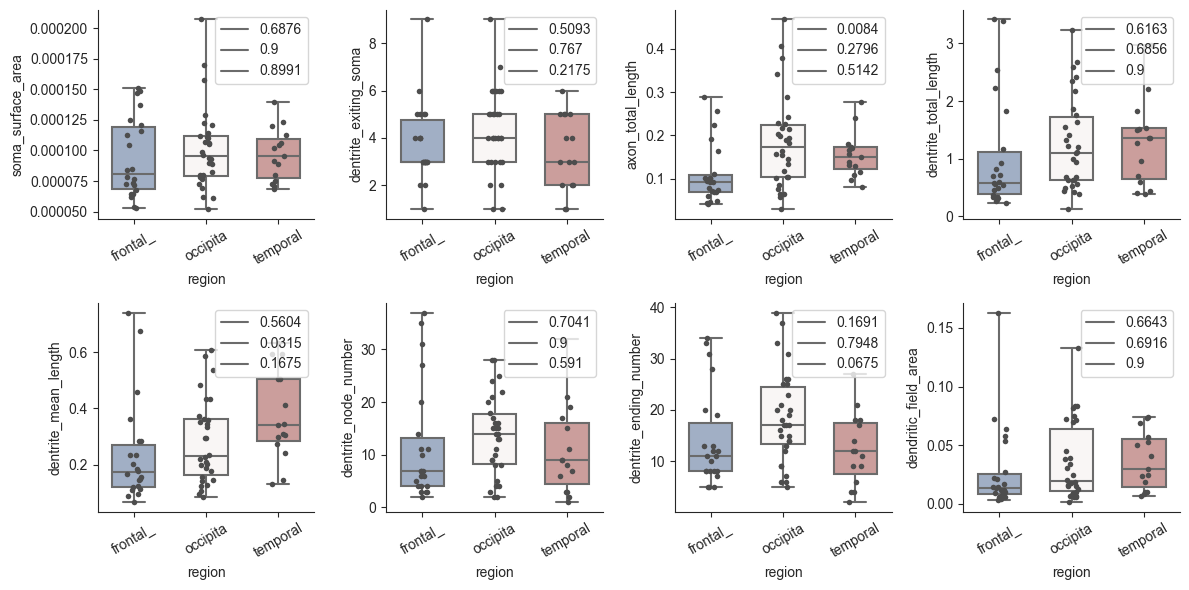

In [ ]:
'''
features of morphology
'''
root_dir=r'F:\jcy\humen_brain\electrophysiology\reconstruction\biotin_reconstructed\all\img_procession'
features_mopho =pd.read_csv(root_dir+'\\features.csv')
features=['soma_surface_area','dentrite_exiting_soma','axon_total_length','dentrite_total_length',\
          'dentrite_mean_length','dentrite_node_number','dentrite_ending_number','dendritic_field_area']
features_mopho.fillna(method = 'pad', axis =0, inplace=True, limit=None)

f, ax = plt.subplots(nrows=2, ncols=4,figsize=(12, 6))
sns.set_style(style="ticks")
for i,parameters in enumerate(features):
    print(f'parameter{parameters}：')
    diff1,diff2=my_oneWayAnova(features_mopho,cata_name='region',num_name=parameters)

    plt.subplot(2,4,i+1)
    # Plot the orbital period with horizontal boxes
    sns.boxplot(x="region", y=parameters, data=features_mopho,whis=[0, 100], width=.6, palette="vlag")
    plt.legend(diff2['p-adj'],loc=1)

    # Add in points to show each observation
    sns.stripplot(x="region", y=parameters, data=features_mopho,size=4, color=".3", linewidth=0)
    sns.despine()
    plt.xticks(rotation=30)

f.tight_layout()
plt.savefig(root_dir+'\\properties_morphology.pdf')

In [14]:
fpath = r'F:\jcy\humen_brain\electrophysiology\reconstruction\homer_reconstructed'
root=Path(fpath)
file_info=[]
file_info = scan_file(root,file_info)
df = pd.DataFrame(file_info, columns=['filename', 'ext', 'dir'])

for fname, dir in zip(df.filename, df.dir):

    fpath = os.path.join(dir, fname)
    print(fpath)

F:\jcy\humen_brain\electrophysiology\reconstruction\homer_reconstructed\frontal\pv_homer\frontal_lobe_1207_slice1_local1_roi1_cell3.tif
F:\jcy\humen_brain\electrophysiology\reconstruction\homer_reconstructed\frontal\pv_homer\frontal_lobe_1207_slice1_local1_roi1_cell6.tif
F:\jcy\humen_brain\electrophysiology\reconstruction\homer_reconstructed\frontal\pv_homer\frontal_lobe_1207_slice1_local1_roi2_cell1.tif
F:\jcy\humen_brain\electrophysiology\reconstruction\homer_reconstructed\frontal\pv_homer\frontal_lobe_1207_slice1_local1_roi2_cell2.tif
F:\jcy\humen_brain\electrophysiology\reconstruction\homer_reconstructed\frontal\pv_homer\frontal_lobe_1207_slice1_local1_roi2_cell4.tif
F:\jcy\humen_brain\electrophysiology\reconstruction\homer_reconstructed\frontal\pv_homer\frontal_lobe_1207_slice1_local1_roi3_cell1.tif
F:\jcy\humen_brain\electrophysiology\reconstruction\homer_reconstructed\frontal\pv_homer\frontal_lobe_1207_slice1_local1_roi3_cell3.tif
F:\jcy\humen_brain\electrophysiology\reconstruct

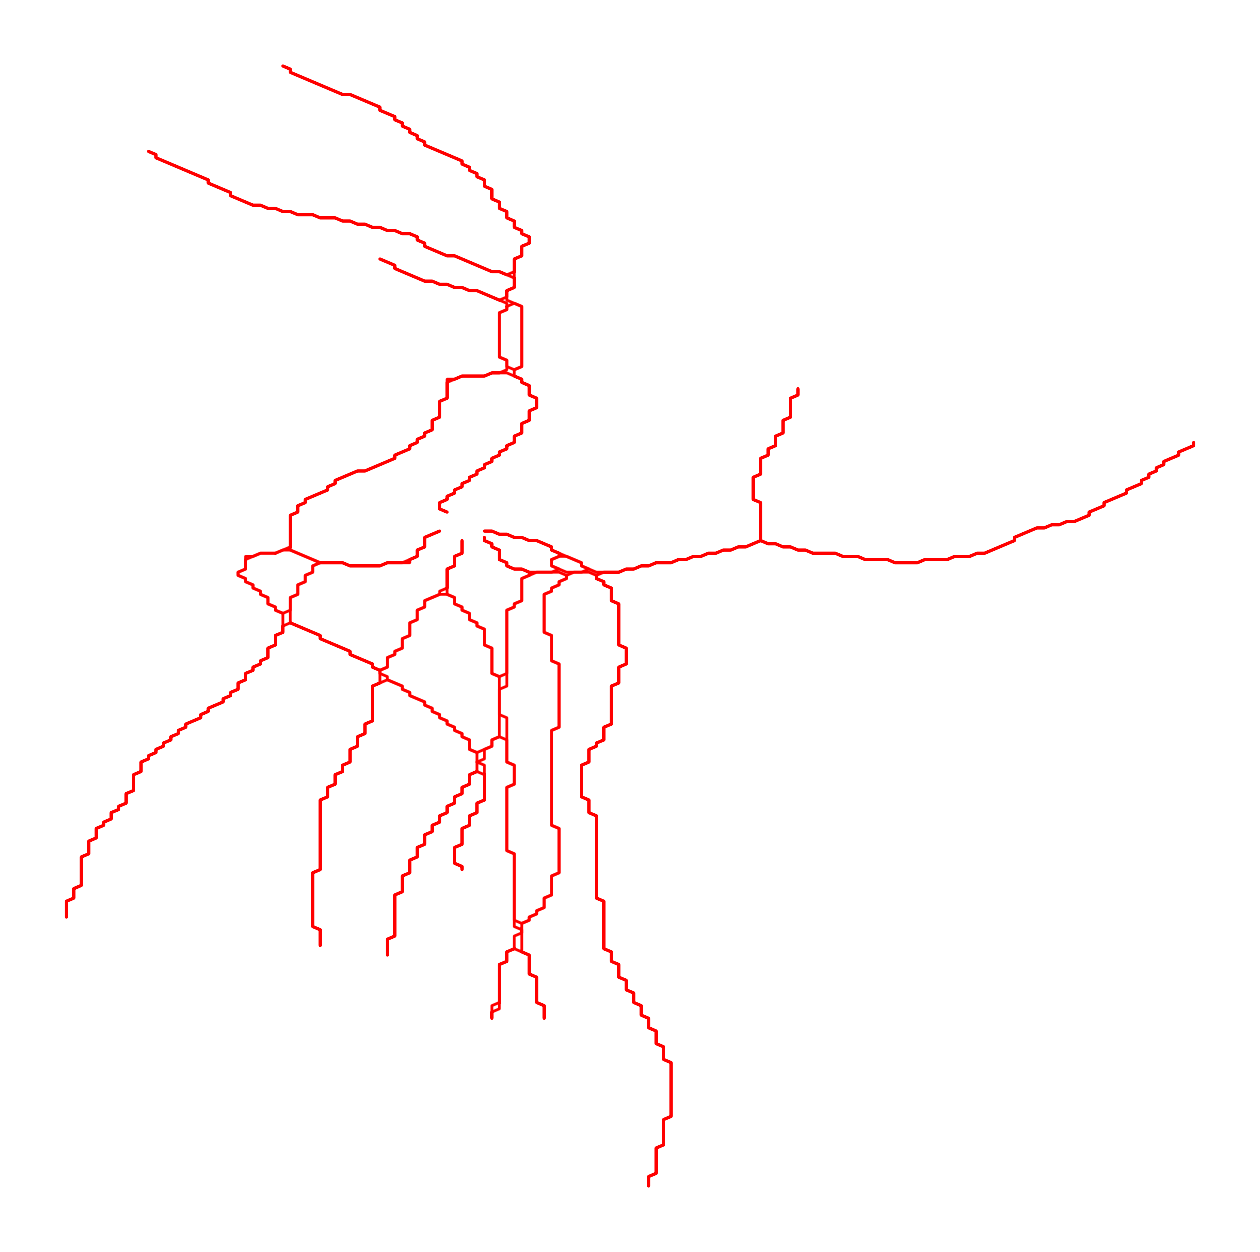

In [ ]:
root=r'F:\jcy\humen_brain\electrophysiology\reconstruction\homer_reconstructed\frontal\pv_homer'
fpath =root+'\\frontal_lobe_1207_slice1_local1_roi1_cell3.tif'

x = np.array(Image.open(fpath))

r, g, b = x[:,:,0], x[:,:,1], x[:,:,2]

axon_branch = np.where((r == 128) & (g == 128) & (b >= 192), 255, 0).astype(np.uint8)
dend_branch = np.where((r == 255) & (g == 128) & (b == 0), 255, 0).astype(np.uint8)

contours, _ = cv2.findContours(dend_branch, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

rings = [np.array(c).reshape([-1, 2]) for c in contours]

# adjust coordinate system to the image coordinate system
max_x, max_y, min_x, min_y = 0, 0, 0, 0
for ring in rings:
    max_x = max(max_x, ring.max(axis=0)[0])
    max_y = max(max_y, ring.max(axis=0)[1])
    min_x = max(min_x, ring.min(axis=0)[0])
    min_y = max(min_y, ring.min(axis=0)[1])

plt.figure(figsize=(16, 16))

plot_dict = {"color" : "r", "linewidth" : 2.0}

for _, ring in enumerate(rings):
    close_ring = np.vstack((ring, ring[0]))
    xx = close_ring[..., 0]
    yy = max_y - close_ring[..., 1]

    plt.plot(xx, yy, **plot_dict)

plt.axis("off")

plt.savefig(root+'\\dendrite2.svg')

plt.show()